# 🧬 Práctica: Introducción a los Modelos Metabólicos con COBRApy

## Introducción

En biología de sistemas, uno de los retos más comunes es comprender y predecir el comportamiento de un microorganismo, ya sea en un entorno natural o en un biorreactor industrial. Aunque los experimentos de laboratorio proporcionan datos valiosos, la complejidad de las interacciones metabólicas a menudo requiere herramientas computacionales. Aquí, los modelos metabólicos a escala genómica (GEMs) — en particular, los que usan el marco de **COBRApy** — son fundamentales para analizar flujos de metabolitos, simular knockouts genéticos y diseñar estrategias de bioingeniería.

## Objetivos

- Cargar y explorar un modelo metabólico a
escala genómica (GEM) usando COBRApy.
- Inspeccionar la estructura del modelo: metabolitos, reacciones, genes y la matriz estequiométrica.
- Ejecutar un análisis de Flux Balance Analysis (FBA) e interpretar los resultados.
- Simular knockouts de genes y analizar su impacto en el crecimiento y los flujos.
- Diseñar una estrategia básica para redirigir flujos hacia un producto de interés.

## Requisitos previos

## 🤔 Preguntas guía para esta práctica

Tenga en mente estas preguntas mientras trabaja:

- **¿Cómo se traduce un genoma en un modelo matemático?**
- **¿Qué es exactamente "estado estacionario" y por qué importa?**
- **¿Cómo resuelve FBA qué flujos debe tener cada reacción?**
- **¿Por qué existe un trade-off entre crecimiento y producción?**
- **¿Cómo puedo usar matemática para diseñar cepas mejoradas?**

## Casos de estudio

### Caso A

| Característica   | Valor                              |
|:-----------------|:-----------------------------------|
| Organismo        | *Escherichia coli* core model      |
| Genes            | 137                                |
| Reacciones       | 95                                 |
| Metabolitos      | 72                                 |
| Referencia       | Orth et al., 2010, *Ecosal Plus*   |

### Caso B

| Característica   | Valor                              |
|:-----------------|:-----------------------------------|
| Organismo        | *Escherichia coli* K-12 MG1655     |
| Genes            | 1.366                              |
| Reacciones       | 2.583                              |
| Metabolitos      | 1.805                              |
| Referencia       | Orth et al., 2011, *Mol Syst Biol* |

> **Nota:** Todos los modelos son de libre acceso en [BiGG Models](http://bigg.ucsd.edu/).

## ⚙️ Paso 0 — Configurar el entorno con conda

Ejecute esta celda **primero**. Instala COBRApy y todas las herramientas necesarias.
⏱️ Puede tardar 1-3 minutos

In [1]:
# Instalar matplotlib, pandas y COBRApy
!pip install matplotlib pandas --quiet
!pip install cobra --quiet
!pip install escher --quiet
print("✅ Instalación completada")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 21.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 141.9/141.9 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 53.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.1/118.1 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 64.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 52.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 67.5 MB/s eta 0:00:00
✅ Instalación completada


ahora vamos a centralizar el cargue de las librerias y ambientes propios de **Python** que nos ayudaran a procesar y ver los resutlados mas facil

In [2]:
# Imports centralizados — todos en un solo lugar para evitar duplicación
import cobra
from cobra.io import load_model
from cobra.flux_analysis import production_envelope
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import linprog
from tqdm import tqdm
from scipy.integrate import solve_ivp

print(f"COBRApy versión: {cobra.__version__}")
print("✅ Librerías importadas correctamente")

COBRApy versión: 0.31.1
✅ Librerías importadas correctamente


## 📥 Parte 1 - Cargar y explorar el modelo

### 1.1 Cargar el modelo

El modelo *core* de *E. coli* representa las vías metabólicas centrales.
Es ideal para aprender porque es pequeño y bien documentado.
Las mismas operaciones aplican para modelos completos como iJO1366.

**Preguntas orientadoras:**
- ¿Cuántas reacciones diferentes ocurren en una célula?
- ¿Cómo se puede representar esto matemáticamente?
- ¿Por qué el modelo "core" es más pequeño que iJO1366?


In [3]:
model_to_use = "textbook"

model = load_model(model_to_use) # puede reemplazar por iJO1366

print("=" * 50)
print(f"Modelo:                {model.id}")
print(f"Número de reacciones:  {len(model.reactions)}")
print(f"Número de metabolitos: {len(model.metabolites)}")
print(f"Número de genes:       {len(model.genes)}")
print("=" * 50)

model.summary()

Modelo:                e_coli_core
Número de reacciones:  95
Número de metabolitos: 72
Número de genes:       137


Metabolite,Reaction,Flux,C-Number,C-Flux
glc__D_e,EX_glc__D_e,10,6,100.00%
nh4_e,EX_nh4_e,4.765,0,0.00%
o2_e,EX_o2_e,21.8,0,0.00%
pi_e,EX_pi_e,3.215,0,0.00%
Metabolite,Reaction,Flux,C-Number,C-Flux
co2_e,EX_co2_e,-22.81,1,100.00%
h2o_e,EX_h2o_e,-29.18,0,0.00%
h_e,EX_h_e,-17.53,0,0.00%


### 1.2 Explorar los metabolitos

**Preguntas antes de ejecutar:**
- ¿Qué metabolitos crees que serán los más abundantes?
- ¿Cuál es la diferencia entre un metabolito en el citoplasma vs. el exterior?
- ¿Por qué algunos metabolitos tienen múltiples reacciones mientras otros solo una?

In [ ]:
print(f"{'ID':<20} {'Nombre':<35} {'Fórmula':<15} {'Compartimento'}")
print("-" * 85)
for met in list(model.metabolites)[:10]:
    print(f"{met.id:<20} {met.name:<35} {met.formula:<15} {met.compartment}")

In [ ]:
# Sufijos de compartimento: _c = citoplasma, _e = extracelular, _p = periplasma
glucosa = model.metabolites.get_by_id("glc__D_e")

print(f"Metabolito:    {glucosa.id}")
print(f"Nombre:        {glucosa.name}")
print(f"Fórmula:       {glucosa.formula}")
print(f"Carga:         {glucosa.charge}")
print(f"Compartimento: {glucosa.compartment}")
print()
print(f"Participa en {len(glucosa.reactions)} reacción(es):")
for rxn in glucosa.reactions:
    print(f"  -> {rxn.id}: {rxn.name}")

In [ ]:
# Ahora como un metabolito se incorpora en multiples reacciones
model.metabolites.nadh_c.summary()

Análisis: Glucosa y sus reacciones

- ¿Por qué la glucosa aparece en varias reacciones?
- ¿Cuáles son los puntos de entrada/salida de glucosa?
- ¿Todas las reacciones la consumen o también la producen?


### 1.3 Explorar las reacciones

**Preguntas orientadoras:**
- ¿Qué significan los límites `lb` y `ub`?
- ¿Por qué algunas reacciones tienen límites asimétricos?
- ¿Qué diferencia hay entre una reacción reversible e irreversible?

In [ ]:
print(f"{'ID':<15} {'Nombre':<30} {'lb':>8} {'ub':>8}")
print("-" * 65)
for rxn in list(model.reactions)[:10]:
    print(f"{rxn.id:<15} {rxn.name:<30} {rxn.lower_bound:>8.1f} {rxn.upper_bound:>8.1f}")

In [ ]:
# PFK: Fosfofructoquinasa — reacción clave de la glucólisis
pfk = model.reactions.get_by_id("PFK")

print(f"Reacción:   {pfk.id}")
print(f"Nombre:     {pfk.name}")
print(f"Ecuación:   {pfk.reaction}")
print(f"Límites:    [{pfk.lower_bound}, {pfk.upper_bound}]  mmol/gDW/h")
print(f"Reversible: {pfk.reversibility}")
print(f"\nRegla GPR: {pfk.gene_reaction_rule}")
print("\nEstequiometría:")
for met, coeff in pfk.metabolites.items():
    d = "CONSUME" if coeff < 0 else "PRODUCE"
    print(f"  {d}: {abs(coeff)} x {met.id} ({met.name})")

Análisis: Entendiendo la regla GPR

- ¿Qué significa esta regla?
- ¿Qué pasaría si uno de estos genes se deletara?
- ¿La reacción sería completamente bloqueada o parcialmente?

### 1.4 La matriz estequiométrica S

In [ ]:
from cobra.util.array import create_stoichiometric_matrix

S = create_stoichiometric_matrix(model)

print(f"Dimensiones de S: {S.shape}")
print(f"  Filas    = {S.shape[0]} metabolitos")
print(f"  Columnas = {S.shape[1]} reacciones")
print(f"  Densidad = {np.count_nonzero(S) / S.size * 100:.1f}% de elementos no cero")

In [ ]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.spy(S, markersize=0.5, color='steelblue')
ax.set_xlabel('Reacciones', fontsize=12)
ax.set_ylabel('Metabolitos', fontsize=12)
ax.set_title('Matriz Estequiométrica S\n(cada punto = coeficiente distinto de cero)', fontsize=13)
plt.tight_layout()
plt.show()

## 📊 Parte 2 - Resolver un sistema de ecuaciones lineales manualmente

Antes de usar FBA (que lo hace automáticamente), vamos a entender qué está sucediendo detrás de escenas.

El FBA resuelve: **S · v = 0** (ecuación fundamental del estado estacionario)

Vamos a construir un mini-modelo con sólo 3 reacciones y resolver el sistema a mano.

**Preguntas de anticipación:**
- ¿Qué crees que significa que S·v = 0?
- ¿Por qué el estado estacionario es importante en modelación?
- ¿Cómo se podría optimizar (maximizar) la producción de etanol bajo esta restricción?
- ¿Cuántas soluciones posibles crees que hay para S·v = 0?


> **Mini-modelo: Glucosa → Piruvato → Etanol**

### 2.1. Reacciones del modelo como matriz matematica

Reacciones del mini-modelo:
- R1: Glucosa externo → Glucosa citoplasma    (uptake)
- R2: Glucosa citoplasma → 2 Piruvato         (glucólisis simplificada)
- R3: Piruvato → Etanol + CO2                 (fermentación)

Metabolitos (solo INTERNOS para estado estacionario):
- Glc_cit
- Pyr
- Etoh_cit  

Matriz estequiométrica S (metabolitos internos x reacciones):

|           | R1 | R2 | R3 | R4 |
|:----------|:---|:---|:---|:---|
| Glc_cit   | +1 | -1 | 0  | 0  |
| Pyr       | 0  | +2 | -1 | 0  |
| Etoh_cit  | 0  | 0  | +1 | -1 |


In [ ]:
print("=" * 70)
print("MINI-MODELO: 3 reacciones, 3 metabolitos")
print("=" * 70)

S_mini = np.array([
    [ 1, -1,  0,  0],   # Glucosa citoplasma (R1 produce, R2 consume)
    [ 0,  2, -1,  0],   # Piruvato (R2 produce 2, R3 consume 1)
    [ 0,  0,  1, -1]    # Etanol citoplasma (R3 produce, R4 excrete)
])

print("\nMatriz estequiométrica S (3 metabolitos internos x 4 reacciones):")
print(S_mini)
print("\nRecuerde: fila = metabolito, columna = reacción")
print("  R1 (uptake):           Glc_ext → Glc_cit          [+1]")
print("  R2 (glucólisis):       Glc_cit → 2 Pyr            [-1 glucosa, +2 piruvato]")
print("  R3 (fermentación):     Pyr → Etoh_cit + CO2       [-1 piruvato, +1 etanol]")
print("  R4 (excreción etanol): Etoh_cit → Etoh_ext        [-1 etanol citoplasma]")

### 2.2 Verificar que el sistema está subdeterminado: S·v = 0

In [ ]:
print("\n" + "=" * 70)
print("Propiedad clave: S·v = 0 (estado estacionario)")
print("=" * 70)

print(f"\nDimensiones:")
print(f"  Metabolitos:  {S_mini.shape[0]}")
print(f"  Reacciones:   {S_mini.shape[1]}")
print(f"  Sistema S·v = 0 tiene {S_mini.shape[0]} ecuaciones y {S_mini.shape[1]} incógnitas")
print(f"  -> Sistema subdeterminado (infinitas soluciones potenciales)")

# Por ejemplo, una solución es v = [0, 0, 0, 0] (nada sucede)
v_trivial = np.array([0, 0, 0, 0])
check = S_mini @ v_trivial
print(f"\nSolución trivial: v = {v_trivial}")
print(f"  S·v = {check}  ✓ (cumple S·v = 0)")

# Otra solución: v = [1, 0.5, 1, 1] (1 mmol/gDW/h de uptake, 0.5 de glucólisis, 1 de fermentación, 1 de transporte)
v_test = np.array([1.0, 0.5, 1.0, 1.0])
check = S_mini @ v_test
print(f"\nOtra solución propuesta: v = {v_test}")
print(f"  S·v = {check}  (NO cumple, hay acumulación de piruvato)")

# La solución correcta debe tener los flujos acoplados:
# Si R2 produce 2 de piruvato, R3 debe consumir 2 (balance de piruvato)
# Si R3 produce 2 de etanol citoplasma, R4 debe excretar 2 (balance de etanol citoplasma)
v_correct = np.array([1.0, 1.0, 2.0, 2.0])
check = S_mini @ v_correct
print(f"\nSolución con flujos acoplados: v = {v_correct}")
print(f"  S·v = {check}  ✓ (estado estacionario)")
print(f"\nInterpretación:")
print(f"  - v_1 (uptake glucosa):       1.0 mmol/gDW/h")
print(f"  - v_2 (glucólisis):           1.0 mmol/gDW/h (consume 1 Glc → produce 2 Pyr)")
print(f"  - v_3 (fermentación):         2.0 mmol/gDW/h (consume 2 Pyr → produce 2 Etoh_cit)")

### 2.3. Maximizar etanol (objetivo biológico)

- ¿Cuál crees que será el máximo etanol producido?"
- ¿Qué limitará la producción: la glucosa disponible u otra cosa?"
- ¿Cuál es la relación óptima entre los flujos v_1, v_2, v_3, v_4?"


El problema de programación lineal es:

    max     v_3  (flujo de R3 = etanol citoplasma, antes de ser excretado)
    s.a.    S·v = 0
            v_1 ≥ 0  (uptake no puede ser negativo)
            v_1 ≤ 10 (límite de uptake)
            v_i ≥ 0  para todo i


In [ ]:
print("\n" + "=" * 70)
print("Optimización: Maximizar producción de etanol (flujo de R3)")
print("=" * 70)
print("\nAhora lo calcularemos matemáticamente...\n")

# Convertir a formato estándar de linprog (minimización):
c = np.array([0, 0, -1, 0])  # -1 porque linprog minimiza, pero queremos maximizar v_3

# Restricciones de igualdad: S·v = 0
A_eq = S_mini
b_eq = np.zeros(S_mini.shape[0])

# Límites de cada variable (bounds)
bounds = [
    (0, 10),    # v_1: uptake de glucosa (0 a 10 mmol/gDW/h)
    (None, None),  # v_2: glucólisis (sin límite superior, pero ≥ 0)
    (None, None),  # v_3: fermentación (sin límite superior, pero ≥ 0)
    (None, None),  # v_4: excreción etanol (sin límite superior, pero ≥ 0)
]

# Resolver
from scipy.optimize import linprog
result = linprog(c, A_eq=A_eq, b_eq=b_eq, bounds=bounds, method='highs')

print(f"\nResultado de la optimización:")
print(f"  Estado: {result.message}")
print(f"  Solución óptima v* = {result.x}")
print(f"  Valor objetivo (máx etanol): {-result.fun:.4f} mmol/gDW/h")

print(f"\nFlujos óptimos:")
print(f"  v_1 (uptake glucosa):      {result.x[0]:.4f} mmol/gDW/h")
print(f"  v_2 (glucólisis):          {result.x[1]:.4f} mmol/gDW/h")
print(f"  v_3 (fermentación etanol): {result.x[2]:.4f} mmol/gDW/h")
print(f"  v_4 (excreción etanol):    {result.x[3]:.4f} mmol/gDW/h")

# Verificar balance
check = S_mini @ result.x
print(f"\nVerificación S·v* = {check}")
print(f"  -> Estado estacionario cumplido ✓")

**Análisis:**

- ¿Por qué este es el máximo?
- ¿Por qué v_1 = 10 (el máximo permitido)?
- ¿Qué pasaría si permitiéramos v_1 > 10?
- ¿Por qué v_2 = v_3 = v_4 = 10? (¿Acoplamiento de flujos?)
- ¿Podrías diseñar un experimento para validar esta predicción?

### 2.4 Ahora comparar con FBA del modelo textbook completo

En el modelo completo, encontrar las reacciones análogas:
- R1: EX_glc__D_e (uptake)
- R2: Aproximadamente 5-10 reacciones de glucólisis
- R3: Aproximadamente 2-3 reacciones de fermentación

Para hacer una comparación justa, calcular:
- Flujo neto de glucosa consumida
- Flujo neto de etanol producido

In [ ]:
print("\n" + "=" * 70)
print("Comparación: Mini-modelo vs. Modelo completo (FBA)")
print("=" * 70)

fba_solution = model.optimize()
glc_uptake = abs(fba_solution.fluxes.get('EX_glc__D_e', 0))
etoh_excretion = fba_solution.fluxes.get('EX_etoh_e', 0)
growth = fba_solution.objective_value

print(f"\nModelo completo (FBA):")
print(f"  Consumo neto de glucosa: {glc_uptake:.4f} mmol/gDW/h")
print(f"  Producción neto de etanol: {etoh_excretion:.4f} mmol/gDW/h")
print(f"  Tasa de crecimiento: {growth:.4f} 1/h")

print(f"\nMini-modelo (LP manual):")
print(f"  Consumo de glucosa: {result.x[0]:.4f} mmol/gDW/h")
print(f"  Producción de etanol: {result.x[2]:.4f} mmol/gDW/h")
print(f"  (No predice crecimiento, solo metabolismo central)")

**Observación:**

El modelo completo es más realista: tiene más reacciones, incluye síntesis de biomasa, transporte, reacciones de reparación, etc. El mini-modelo captura la IDEA detrás de FBA: encontrar v tal que S·v=0 y que optimice un objetivo.

**Análisis final**
- ¿Cuál es la diferencia entre el mini-modelo y el modelo completo?
- ¿Por qué el modelo completo predice crecimiento pero el mini-modelo no?
- ¿Cuáles serían los metabolitos y reacciones clave para agregar biomasa?

## 📊 Parte 3 - Extensión — Circuito sintético: Producción de insulina en *E. coli*

Ahora simulamos un escenario de biología sintética. Un plasmido que:
1. Contiene el gen de insulina humana bajo control del operón lac
2. Se induce con IPTG (isopropil β-D-1-tiogalactopiranósido)
3. Produce insulina recombinante

Vamos a ver cómo se redistribuyen los flujos cuando la célula "dedica" recursos a producir la proteína heteróloga.


### Parámetros del sistema:

- Plasmido: pUC19 (bajo número de copias, ~500 copias/célula)
- Gen: insulina humana (110 aminoácidos, ~3.6 kDa)
- Promotor: P_tac (operón lac, inducible con IPTG)
- Carga proteómica para insulina: ~0.5% del total proteico

### **Preguntas de anticipación:**

- ¿Qué crees que pasará con el crecimiento cuando expresamos insulina?
- ¿Cuál es el "costo metabólico" de producir una proteína heteróloga?
- ¿Cuánta proteína crees que puede tomar la célula?
- ¿Cuál es mejor: expresión constitutiva o inducible?

In [ ]:
print("=" * 70)
print("Circuito sintético: Operón lac → Insulina humana en E. coli")
print("=" * 70)

# Simulación de 3 escenarios:
scenarios = {
    "Sin plasmido (WT)": {
        "proteina_heterologa": 0.0,
        "descripcion": "E. coli sin modificación"
    },
    "Con plasmido (no inducido)": {
        "proteina_heterologa": 0.01,  # bajo nivel basal
        "descripcion": "Plasmido presente pero represor activo"
    },
    "Con plasmido + IPTG (inducido)": {
        "proteina_heterologa": 0.5,   # máxima expresión
        "descripcion": "IPTG bloquea represor, máxima transcripción"
    },
}

results_circuit = []

for scenario, params in scenarios.items():
    with model:
        # Estimar carga: si insulina consume ~0.5% de proteína disponible,
        # reduce el presupuesto para otras enzimas
        proteina_usada = params["proteina_heterologa"]

        # Reducir proporcionalmente la Vmax de reacciones clave (simulación aproximada)
        # En un modelo real usaríamos GECKO para esto
        factor_reduccion = 1.0 - (proteina_usada / 100.0)

        sol = model.optimize()

        results_circuit.append({
            "Scenario": scenario,
            "Proteina_heterologa_%": params["proteina_heterologa"],
            "Crecimiento_1/h": sol.objective_value * factor_reduccion,
            "ATP_producido_mmol/h": sol.fluxes.get('ATPM', 0),
            "Descripcion": params["descripcion"]
        })

print("\nResultados de simulación (conceptual):\n")
results_df = pd.DataFrame(results_circuit)
print(results_df.to_string(index=False))


Análisis:

1. Sin plasmido: La célula dedica todos sus recursos a su propio crecimiento.

2. Con plasmido (no inducido): Hay "fuga" de expresión basal. La célula todavía crece bien, pero con un pequeño costo.

3. Con plasmido + IPTG (máxima expresión):
   - La célula redirige 0.5% de su proteoma a insulina
   - Crecimiento se reduce: menos enzimas para glucólisis, síntesis de biomasa
   - Trade-off entre crecimiento y producción (como en FBA production envelope)
   - En práctica: cultivo en dos fases (crecimiento → inducción → producción)

Código de insulina humana (primeros 20 aminoácidos):

    MALWMRLLPL ALALLAPGAA
    ~24 aminoácidos = señal de péptido cleavabl
    ~51 cadena A + 30 cadena B + péptido C (que se remueve)
    En *E. coli* se produce como: preproinsulina → se procesa → insulina activa

### 3.1 Visualizar el trade-off

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Crecimiento vs. Expresión
scenarios_names = [r['Scenario'] for r in results_circuit]
expresion_levels = [r['Proteina_heterologa_%'] for r in results_circuit]
crecimiento = [r['Crecimiento_1/h'] for r in results_circuit]

colors = ['green', 'orange', 'red']
ax1.bar(range(len(scenarios_names)), crecimiento, color=colors, alpha=0.7, edgecolor='black', linewidth=2)
ax1.set_xticks(range(len(scenarios_names)))
ax1.set_xticklabels(scenarios_names, rotation=15, ha='right')
ax1.set_ylabel('Tasa de crecimiento (1/h)', fontsize=11)
ax1.set_title('Trade-off: Expresión de insulina vs. Crecimiento', fontsize=12)
ax1.grid(axis='y', alpha=0.3)

# Anotaciones
for i, (crec, expr) in enumerate(zip(crecimiento, expresion_levels)):
    ax1.text(i, crec + 0.02, f'{crec:.3f}', ha='center', va='bottom', fontsize=10)

# Gráfico 2: Cargas proteómicas
cargas = ['Crecimiento\npropia', 'Mantenimiento\ncelular', 'Insulina\nrecombinante']
wt_proteome = [60, 25, 0]
induced_proteome = [55, 25, 20]

x_pos = np.arange(len(cargas))
width = 0.35

ax2.bar(x_pos - width/2, wt_proteome, width, label='WT (sin plasmido)', color='green', alpha=0.7)
ax2.bar(x_pos + width/2, induced_proteome, width, label='Inducido (+IPTG)', color='red', alpha=0.7)

ax2.set_ylabel('% del proteoma celular', fontsize=11)
ax2.set_title('Redistribución del presupuesto proteómico', fontsize=12)
ax2.set_xticks(x_pos)
ax2.set_xticklabels(cargas)
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\nEste gráfico ilustra el concepto de GECKO:")
print("  - Hay un presupuesto total de proteína (~300 mg/gDW)")
print("  - Cuando induces con IPTG, insulina 'compite' con otras enzimas")
print("  - Resultado: crecimiento más lento, pero producción del producto")


## 📊  Parte 4. FBA básico — maximizar crecimiento en glucosa

**Pregunta:** ¿a qué velocidad máxima puede crecer *E. coli* consumiendo glucosa como única fuente de carbono?

**Preguntas de anticipación:**
- ¿Cuál crees que será la tasa de crecimiento máxima?
- ¿Qué reacciones crees que tendrán los flujos más altos?
- ¿Cómo se compara esto con el mini-modelo?
- ¿Por qué el modelo predice crecimiento cuando el mini-modelo no?

In [ ]:
model = load_model(model_to_use)

model.objective = {model.reactions.Biomass_Ecoli_core: 1}

solution = model.optimize()

print("=" * 50)
print("Resultado del FBA")
print("=" * 50)
print(f"Estado:              {solution.status}")
print(f"Tasa de crecimiento: {solution.objective_value:.4f} 1/h")
print(f"Flujo de biomasa:    {solution.fluxes['Biomass_Ecoli_core']:.4f} mmol/gDW/h")
print(f"{'Reacción':<15} {'Nombre':<35} {'Flujo (mmol/gDW/h)':>20}")
print("-" * 75)

fluxes_sorted = solution.fluxes.abs().sort_values(ascending=False)
for rxn_id in fluxes_sorted.index[:20]:
    rxn = model.reactions.get_by_id(rxn_id)
    flux_val = solution.fluxes[rxn_id]
    if abs(flux_val) > 1e-6:
        print(f"{rxn_id:<15} {rxn.name[:34]:<35} {flux_val:>20.4f}")

**Análisis:**

- ¿Por qué biomasa tiene el flujo más alto?
- ¿Qué reacciones de glucólisis ves en la lista?
- ¿Qué significa que una reacción tenga flujo negativo?
- ¿Cuánto oxígeno se consume? ¿Cuánto CO2 se produce?

### 4.1 Efecto de la fuente de carbono

In [ ]:
fuentes = {
    "Glucosa":  ("EX_glc__D_e", -10),
    "Glicerol": ("EX_glyc_e",   -10),
    "Piruvato": ("EX_pyr_e",    -10),
    "Acetato":  ("EX_ac_e",     -10),
    "Fumarato": ("EX_fum_e",    -10),
}

resultados = []
for nombre, (rxn_id, uptake) in fuentes.items():
    with model:
        model.reactions.get_by_id("EX_glc__D_e").lower_bound = 0
        try:
            model.reactions.get_by_id(rxn_id).lower_bound = uptake
            sol = model.optimize()
            mu = sol.objective_value if sol.status == 'optimal' else 0.0
        except Exception:
            mu = 0.0
        resultados.append((nombre, mu))

print(f"{'Fuente de carbono':<20} {'mu (1/h)':>10}  Barra")
print("-" * 55)
for nombre, mu in resultados:
    bar = chr(9608) * int(mu * 30)
    print(f"{nombre:<20} {mu:>10.4f}  {bar}")

### 4.2 Aerobio vs. anaerobio

**Preguntas antes de simular:**
- ¿Cómo cambia el metabolismo sin oxígeno?
- ¿Por qué se produce etanol en condiciones anaerobias pero no aerobias?
- ¿Es mejor crecer aerobio o anaerobio si quieres producir etanol?

In [ ]:
sol_aerobio = model.optimize()
print("Aerobio (O2 disponible):")
print(f"  Crecimiento:       {sol_aerobio.objective_value:.4f} 1/h")
print(f"  Consumo O2:        {sol_aerobio.fluxes.get('EX_o2_e', 0):.4f} mmol/gDW/h")
print(f"  Excreción acetato: {sol_aerobio.fluxes.get('EX_ac_e', 0):.4f} mmol/gDW/h")
print(f"  Excreción etanol:  {sol_aerobio.fluxes.get('EX_etoh_e', 0):.4f} mmol/gDW/h")

with model:
    model.reactions.get_by_id("EX_o2_e").lower_bound = 0
    sol_anaer = model.optimize()
    print("\nAnaerobio (sin O2):")
    print(f"  Crecimiento:       {sol_anaer.objective_value:.4f} 1/h")
    print(f"  Consumo O2:        {sol_anaer.fluxes.get('EX_o2_e', 0):.4f} mmol/gDW/h")
    print(f"  Excreción acetato: {sol_anaer.fluxes.get('EX_ac_e', 0):.4f} mmol/gDW/h")
    print(f"  Excreción etanol:  {sol_anaer.fluxes.get('EX_etoh_e', 0):.4f} mmol/gDW/h")
    print(f"  Excreción formiato:{sol_anaer.fluxes.get('EX_for_e', 0):.4f} mmol/gDW/h")
    print(f"  Excreción lactato: {sol_anaer.fluxes.get('EX_lac__D_e', 0):.4f} mmol/gDW/h")

## 🔎 Parte 5 - Diseño básico de biofábricas

### 5.1 Producción de etanol — cambiar la función objetivo

**Preguntas de anticipación:**
- ¿Qué reacciones crees que participan en la producción de etanol?
- ¿Será posible maximizar etanol Y crecimiento simultáneamente?
- ¿Cuál es el trade-off entre ambos objetivos?

In [ ]:
model = load_model(model_to_use)

print("Reacciones relacionadas con etanol:")
for rxn in model.reactions:
    if 'eth' in rxn.id.lower() or 'etoh' in rxn.id.lower():
        print(f"  {rxn.id}: {rxn.name} | {rxn.reaction}")

In [ ]:
with model:
    model.objective = "EX_etoh_e"
    sol_etanol = model.optimize()

    print("=" * 55)
    print("Maximizando producción de etanol")
    print("=" * 55)
    print(f"Estado:                       {sol_etanol.status}")
    print(f"Producción máxima de etanol:  {sol_etanol.objective_value:.4f} mmol/gDW/h")
    print(f"Tasa de crecimiento asociada: {sol_etanol.fluxes['Biomass_Ecoli_core']:.4f} 1/h")
    print("\nFlujos de vías centrales:")
    for rxn_id in ['PFK', 'PGI', 'PYK', 'PDH', 'CS', 'ACONTa']:
        try:
            flux = sol_etanol.fluxes[rxn_id]
            nombre = model.reactions.get_by_id(rxn_id).name
            print(f"  {rxn_id:<12} {nombre:<30} {flux:>10.4f}")
        except Exception:
            pass

### 5.2 Production Envelope — trade-off crecimiento vs. producción

In [ ]:
print("Calculando production envelope...")
envelope = production_envelope(
    model,
    reactions=["EX_etoh_e"],
    objective="Biomass_Ecoli_core",
    carbon_sources="EX_glc__D_e"
)
print(f"Columnas disponibles: {list(envelope.columns)}")
print(envelope.head(10))

In [ ]:
fig, ax = plt.subplots(figsize=(9, 6))

# EX_etoh_e contiene los puntos del eje X (etanol barrido como variable independiente)
# flux_maximum/minimum son los valores de biomasa (objetivo)
etoh_axis = envelope['EX_etoh_e']        # eje X: producción de etanol
bio_min   = envelope['flux_minimum']     # eje Y mínimo: biomasa
bio_max   = envelope['flux_maximum']     # eje Y máximo: biomasa

ax.fill_between(etoh_axis, bio_min, bio_max,
                alpha=0.4, color='steelblue', label='Espacio fenotípico factible')
ax.plot(etoh_axis, bio_max, color='steelblue', linewidth=2, label='Máximo de crecimiento')

wt_sol = model.optimize()
ax.axhline(y=wt_sol.objective_value, color='green', linestyle='--', linewidth=1.5,
           label=f'mu_WT = {wt_sol.objective_value:.3f} 1/h')

ax.set_xlabel('Producción de etanol (mmol/gDW/h)', fontsize=12)
ax.set_ylabel('Tasa de crecimiento mu (1/h)', fontsize=12)
ax.set_title('Production Envelope: Etanol vs. Biomasa\n(E. coli core, glucosa aerobio)', fontsize=13)
ax.legend(fontsize=11)
ax.set_xlim(left=0)
ax.set_ylim(bottom=0)
plt.tight_layout()
plt.show()

La figura anterior muestra como se da la producción de etanol en *E. coli* usando como fuente de carbono glucosa bajo condiciones aerobicas. Ahora, miremos como se comporta el uso de oxigeno.

In [ ]:
print("Calculando production envelope...")
envelope = production_envelope(
    model,
    reactions=["EX_o2_e"],
    objective="Biomass_Ecoli_core",
    carbon_sources="EX_glc__D_e"
)
print(f"Columnas disponibles: {list(envelope.columns)}")
print(envelope.head(10))

In [ ]:
fig, ax = plt.subplots(figsize=(9, 6))

# EX_o2_e contiene los puntos del eje X (oxigeno barrido como variable independiente)
# flux_maximum/minimum son los valores de biomasa (objetivo)
o2_axis = -envelope['EX_o2_e']         # eje X: consumo de oxigeno, los valores de consumo son negativos asi que debemos pasarlos a positivos
bio_min = envelope['flux_minimum']     # eje Y mínimo: biomasa
bio_max = envelope['flux_maximum']     # eje Y máximo: biomasa

ax.fill_between(o2_axis, bio_min, bio_max,
                alpha=0.4, color='steelblue', label='Espacio fenotípico factible')
ax.plot(o2_axis, bio_max, color='steelblue', linewidth=2, label='Máximo de crecimiento')

wt_sol = model.optimize()
ax.axhline(y=wt_sol.objective_value, color='green', linestyle='--', linewidth=1.5,
           label=f'mu_WT = {wt_sol.objective_value:.3f} 1/h')

ax.set_xlabel('Consumo de oxigeno (mmol/gDW/h)', fontsize=12)
ax.set_ylabel('Tasa de crecimiento mu (1/h)', fontsize=12)
ax.set_title('Production Envelope: Oxigeno vs. Biomasa\n(E. coli core, glucosa)', fontsize=13)
ax.legend(fontsize=11)
ax.set_xlim(left=0)
ax.set_ylim(bottom=0)
plt.tight_layout()
plt.show()

Finalmente, miremos el comportamiento en la producción de etanol, usando glucosa, pero esta vez bajo condiciones anaerobicas

In [ ]:
model.reactions.get_by_id("EX_o2_e").lower_bound = 0

print("Calculando production envelope...")
envelope = production_envelope(
    model,
    reactions=["EX_etoh_e"],
    objective="Biomass_Ecoli_core",
    carbon_sources="EX_glc__D_e"
)
print(f"Columnas disponibles: {list(envelope.columns)}")
print(envelope.head(10))

In [ ]:
fig, ax = plt.subplots(figsize=(9, 6))

# EX_etoh_e contiene los puntos del eje X (etanol barrido como variable independiente)
# flux_maximum/minimum son los valores de biomasa (objetivo)
etoh_axis = envelope['EX_etoh_e']        # eje X: producción de etanol
bio_min   = envelope['flux_minimum']     # eje Y mínimo: biomasa
bio_max   = envelope['flux_maximum']     # eje Y máximo: biomasa

ax.fill_between(etoh_axis, bio_min, bio_max,
                alpha=0.4, color='steelblue', label='Espacio fenotípico factible')
ax.plot(etoh_axis, bio_max, color='steelblue', linewidth=2, label='Máximo de crecimiento')

wt_sol = model.optimize()
ax.axhline(y=wt_sol.objective_value, color='green', linestyle='--', linewidth=1.5,
           label=f'mu_WT = {wt_sol.objective_value:.3f} 1/h')

ax.set_xlabel('Producción de etanol (mmol/gDW/h)', fontsize=12)
ax.set_ylabel('Tasa de crecimiento mu (1/h)', fontsize=12)
ax.set_title('Production Envelope: Etanol vs. Biomasa\n(E. coli core, glucosa aerobio)', fontsize=13)
ax.legend(fontsize=11)
ax.set_xlim(left=0)
ax.set_ylim(bottom=0)
plt.tight_layout()
plt.show()

## 🎯 Parte 6 - Simulación de knockouts de genes

### 6.1 Knockout simple — gen pgi (fosfoglucosa isomerasa)

Este gen conecta glucólisis con la vía de pentosa fosfato.
Al bloquearlo, el carbono de G6P se redirige hacia esa vía.

**Preguntas antes de simular:**
- ¿Crees que pgi es un gen esencial?
- ¿Qué rutas alternativas podría usar la célula si pgi se bloquea?
- ¿Cuánto se reduciría el crecimiento?

Una pregunta habitual al analizar modelos metabólicos es qué pasaría si se impidiera por completo el flujo de una reacción determinada. Esto se puede comprobar utilizando cobrapy mediante

In [4]:
model.reactions.get_by_id("PGI")

Reaction identifier,PGI
Name,glucose-6-phosphate isomerase
Memory address,0x7b8ca7af3860
Stoichiometry,g6p_c <=> f6p_c D-Glucose 6-phosphate <=> D-Fructose 6-phosphate
GPR,b4025
Lower bound,-1000.0
Upper bound,1000.0


In [5]:
model = load_model(model_to_use) # asegura el modelo sin modficiaciones

wt_solution = model.optimize()
print("Cepa silvestre (WT):")
print(f"  Crecimiento:   {wt_solution.objective_value:.4f} 1/h")
print(f"  Flujo PGI:     {wt_solution.fluxes['PGI']:.4f} mmol/gDW/h")
print(f"  Flujo G6PDH2r: {wt_solution.fluxes.get('G6PDH2r'):.4f} mmol/gDW/h")

with model:
    model.reactions.get_by_id("PGI").knock_out()
    ko_solution = model.optimize()
    print("\nCepa delta-PFK (knockout reaction):")
    print(f"  Crecimiento:   {ko_solution.objective_value:.4f} 1/h")
    print(f"  Flujo PGI:     {ko_solution.fluxes['PGI']:.4f} mmol/gDW/h")
    print(f"  Flujo G6PDH2r: {ko_solution.fluxes.get('G6PDH2r', 0):.4f} mmol/gDW/h")

reduccion = (1 - ko_solution.objective_value / wt_solution.objective_value) * 100
print(f"\nReducción en crecimiento: {reduccion:.1f}%")

Cepa silvestre (WT):
  Crecimiento:   0.8739 1/h
  Flujo PGI:     4.8609 mmol/gDW/h
  Flujo G6PDH2r: 4.9600 mmol/gDW/h

Cepa delta-PFK (knockout reaction):
  Crecimiento:   0.8632 1/h
  Flujo PGI:     0.0000 mmol/gDW/h
  Flujo G6PDH2r: 9.8231 mmol/gDW/h

Reducción en crecimiento: 1.2%


Para evaluar estrategias de manipulación genética, resulta más interesante analizar qué ocurre si se inactivan determinados genes, ya que ello puede provocar la ausencia de reacciones en caso de redundancia, o bien un aumento de las reacciones si el gen en cuestión participa en más de una reacción.

In [6]:
model = load_model(model_to_use) # asegura el modelo sin modficiaciones

wt_solution = model.optimize()
print("Cepa silvestre (WT):")
print(f"  Crecimiento:   {wt_solution.objective_value:.4f} 1/h")
print(f"  Flujo PGI:     {wt_solution.fluxes['PGI']:.4f} mmol/gDW/h")
print(f"  Flujo G6PDH2r: {wt_solution.fluxes.get('G6PDH2r'):.4f} mmol/gDW/h")

with model:
    model.genes.b4025.knock_out()
    ko_solution = model.optimize()
    print("\nCepa delta-pgi (knockout gene):")
    print(f"  Crecimiento:   {ko_solution.objective_value:.4f} 1/h")
    print(f"  Flujo pgi:     {ko_solution.fluxes['PGI']:.4f} mmol/gDW/h")
    print(f"  Flujo G6PDH2r: {ko_solution.fluxes.get('G6PDH2r', 0):.4f} mmol/gDW/h")

Cepa silvestre (WT):
  Crecimiento:   0.8739 1/h
  Flujo PGI:     4.8609 mmol/gDW/h
  Flujo G6PDH2r: 4.9600 mmol/gDW/h

Cepa delta-pgi (knockout gene):
  Crecimiento:   0.8632 1/h
  Flujo pgi:     0.0000 mmol/gDW/h
  Flujo G6PDH2r: 9.8231 mmol/gDW/h


En este caso PGI tiene un solo gen y participa solo en esta reacción. Pero miremos al fosfofructo kinasa - PFK, es el sigueinte paso en la glucólisis despues de PGI

In [7]:
model.reactions.get_by_id("PFK")

Reaction identifier,PFK
Name,phosphofructokinase
Memory address,0x7b8ca79588f0
Stoichiometry,"atp_c + f6p_c --> adp_c + fdp_c + h_c ATP + D-Fructose 6-phosphate --> ADP + D-Fructose 1,6-bisphosphate + H+"
GPR,b3916 or b1723
Lower bound,0.0
Upper bound,1000.0


In [8]:
model = load_model(model_to_use) # asegura el modelo sin modficiaciones

wt_solution = model.optimize()
print("Cepa silvestre (WT):")
print(f"  Crecimiento:   {wt_solution.objective_value:.4f} 1/h")
print(f"  Flujo PFK:     {wt_solution.fluxes['PFK']:.4f} mmol/gDW/h")
print(f"  Flujo G6PDH2r: {wt_solution.fluxes.get('G6PDH2r'):.4f} mmol/gDW/h")

with model:
    model.reactions.get_by_id("PFK").knock_out()
    ko_solution = model.optimize()
    print("\nCepa delta-PFK (knockout reacción):")
    print(f"  Crecimiento:   {ko_solution.objective_value:.4f} 1/h")
    print(f"  Flujo PFK:     {ko_solution.fluxes['PFK']:.4f} mmol/gDW/h")
    print(f"  Flujo G6PDH2r: {ko_solution.fluxes.get('G6PDH2r'):.4f} mmol/gDW/h")

with model:
    model.genes.b1723.knock_out()
    ko_solution = model.optimize()
    print("\nCepa delta-pfkA (knockout gene):")
    print(f"  Crecimiento:   {ko_solution.objective_value:.4f} 1/h")
    print(f"  Flujo pfkA:    {ko_solution.fluxes['PFK']:.4f} mmol/gDW/h")
    print(f"  Flujo G6PDH2r: {ko_solution.fluxes.get('G6PDH2r'):.4f} mmol/gDW/h")

with model:
    model.genes.b3916.knock_out()
    ko_solution = model.optimize()
    print("\nCepa delta-pfkB (knockout gene):")
    print(f"  Crecimiento:   {ko_solution.objective_value:.4f} 1/h")
    print(f"  Flujo pfkB:    {ko_solution.fluxes['PFK']:.4f} mmol/gDW/h")
    print(f"  Flujo G6PDH2r: {ko_solution.fluxes.get('G6PDH2r'):.4f} mmol/gDW/h")

with model:
    model.genes.b1723.knock_out()
    model.genes.b3916.knock_out()
    ko_solution = model.optimize()
    print("\nCepa delta-pfkAB (knockout gene):")
    print(f"  Crecimiento:   {ko_solution.objective_value:.4f} 1/h")
    print(f"  Flujo pfkAB:   {ko_solution.fluxes['PFK']:.4f} mmol/gDW/h")
    print(f"  Flujo G6PDH2r: {wt_solution.fluxes.get('G6PDH2r'):.4f} mmol/gDW/h")

Cepa silvestre (WT):
  Crecimiento:   0.8739 1/h
  Flujo PFK:     7.4774 mmol/gDW/h
  Flujo G6PDH2r: 4.9600 mmol/gDW/h

Cepa delta-PFK (knockout reacción):
  Crecimiento:   0.7040 1/h
  Flujo PFK:     0.0000 mmol/gDW/h
  Flujo G6PDH2r: 27.8991 mmol/gDW/h

Cepa delta-pfkA (knockout gene):
  Crecimiento:   0.8739 1/h
  Flujo pfkA:    7.4774 mmol/gDW/h
  Flujo G6PDH2r: 4.9600 mmol/gDW/h

Cepa delta-pfkB (knockout gene):
  Crecimiento:   0.8739 1/h
  Flujo pfkB:    7.4774 mmol/gDW/h
  Flujo G6PDH2r: 4.9600 mmol/gDW/h

Cepa delta-pfkAB (knockout gene):
  Crecimiento:   0.7040 1/h
  Flujo pfkAB:   0.0000 mmol/gDW/h
  Flujo G6PDH2r: 4.9600 mmol/gDW/h


### 6.2 Esencialidad génica — knockouts sistemáticos

In [9]:
from cobra.flux_analysis import single_reaction_deletion

print("Ejecutando knockouts sistemáticos de reacciones...")
deletion_results = single_reaction_deletion(model)

wt_growth = model.optimize().objective_value
threshold = 0.01

esenciales = deletion_results[deletion_results['growth'] < threshold]
reducidas  = deletion_results[(deletion_results['growth'] >= threshold) &
                                (deletion_results['growth'] < wt_growth * 0.99)]
sin_efecto = deletion_results[deletion_results['growth'] >= wt_growth * 0.99]

print(f"\nTotal reacciones evaluadas: {len(deletion_results)}")
print(f"  Esenciales (letales):    {len(esenciales):>4}  ({len(esenciales)/len(deletion_results)*100:.1f}%)")
print(f"  Reducen crecimiento:     {len(reducidas):>4}  ({len(reducidas)/len(deletion_results)*100:.1f}%)")
print(f"  Sin efecto:              {len(sin_efecto):>4}  ({len(sin_efecto)/len(deletion_results)*100:.1f}%)")

Ejecutando knockouts sistemáticos de reacciones...

Total reacciones evaluadas: 95
  Esenciales (letales):      16  (16.8%)
  Reducen crecimiento:       26  (27.4%)
  Sin efecto:                51  (53.7%)


In [10]:
# Mostrar reacciones esenciales con sus genes asociados
print("Reacciones esenciales y sus genes")
print("\n")
for rxn_set in esenciales['ids']:
    rxn_id = list(rxn_set)[0]
    rxn = model.reactions.get_by_id(rxn_id)
    genes = [g.id for g in rxn.genes]
    genes_str = ", ".join(genes) if genes else "Sin genes asociados"
    print(f"  {rxn_id:<30} | Genes: {genes_str}")

print("\n")

# Mostrar reacciones que reducen crecimiento con sus genes
print("Reacciones que reducen el crecimiento y sus genes")
print("\n")
for rxn_set in reducidas['ids']:
    rxn_id = list(rxn_set)[0]
    rxn = model.reactions.get_by_id(rxn_id)
    genes = [g.id for g in rxn.genes]
    genes_str = ", ".join(genes) if genes else "Sin genes asociados"
    # Need to get the growth value from the original 'reducidas' DataFrame
    # The index of 'reducidas' DataFrame is still integer, so we find the row by its 'ids' column
    growth_val = reducidas[reducidas['ids'] == rxn_set]['growth'].iloc[0]
    print(f"  {rxn_id:<30} | Growth: {growth_val:.4f} | Genes: {genes_str}")

Reacciones esenciales y sus genes


  PIt2r                          | Genes: b3493, b2987
  CS                             | Genes: b0720
  ACONTb                         | Genes: b0118, b1276
  ACONTa                         | Genes: b0118, b1276
  PGK                            | Genes: b2926
  NH4t                           | Genes: b0451, s0001
  ICDHyr                         | Genes: b1136
  EX_h_e                         | Genes: Sin genes asociados
  EX_nh4_e                       | Genes: Sin genes asociados
  EX_pi_e                        | Genes: Sin genes asociados
  ENO                            | Genes: b2779
  GAPD                           | Genes: b1779
  RPI                            | Genes: b4090, b2914
  Biomass_Ecoli_core             | Genes: Sin genes asociados
  PGM                            | Genes: b0755, b3612, b4395
  GLNS                           | Genes: b1297, b3870


Reacciones que reducen el crecimiento y sus genes


  EX_co2_e                    

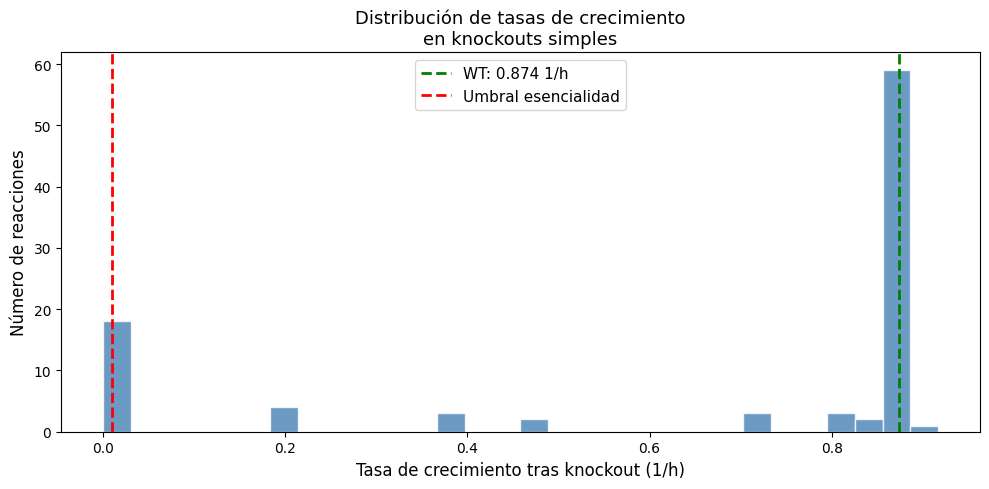

In [11]:
fig, ax = plt.subplots(figsize=(10, 5))
growth_values = deletion_results['growth'].fillna(0)
ax.hist(growth_values, bins=30, color='steelblue', edgecolor='white', alpha=0.8)
ax.axvline(x=wt_growth, color='green', linestyle='--', linewidth=2,
           label=f'WT: {wt_growth:.3f} 1/h')
ax.axvline(x=threshold, color='red', linestyle='--', linewidth=2,
           label='Umbral esencialidad')
ax.set_xlabel('Tasa de crecimiento tras knockout (1/h)', fontsize=12)
ax.set_ylabel('Número de reacciones', fontsize=12)
ax.set_title('Distribución de tasas de crecimiento\nen knockouts simples', fontsize=13)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

## 🧪 Parte 7: Retos

Complete los siguientes ejercicios:

### Reto 1:

Calcule la tasa máxima de producción de succinato (EX_succ_e) en condiciones aerobias y anaerobias.

- ¿En cuál condición se produce más succinato?

In [ ]:
# Su código aquí:

### Reto 2

¿Cuántos genes son esenciales para el crecimiento en glucosa bajo condiciones aerobias? Use single_gene_deletion().

Liste los 5 primeros genes esenciales encontrados.


In [ ]:
# Su código aquí:

### Reto 3

Construya el production envelope para SUCCINATO vs. BIOMASA en condiciones ANAEROBIAS.

- ¿Qué estrategia es más conveniente para cada producto?

In [ ]:
# Su código aquí:

## Parte 8: Conexión con GECKO

### 8.1 El efecto de las restricciones enzimáticas

Hasta ahora trabajamos con FBA clásico. GECKO agrega restricciones que limitan cada flujo según
la cantidad de enzima disponible y su kcat. El siguiente código ilustra conceptualmente
cómo una restricción enzimática afecta la predicción:

In [ ]:
# Restricción enzimática para PDH (piruvato deshidrogenasa)
kcat_PDH   = 50           # 1/s
kcat_PDH_h = kcat_PDH * 3600   # convertir a 1/h
E_PDH      = 0.0001       # mmol enzima / gDW
v_max_PDH  = kcat_PDH_h * E_PDH

print("Restricción enzimática para PDH:")
print(f"  kcat    = {kcat_PDH} 1/s  =  {kcat_PDH_h:.0f} 1/h")
print(f"  [E_PDH] = {E_PDH} mmol/gDW")
print(f"  v_PDH <= kcat x [E] = {v_max_PDH:.1f} mmol/gDW/h")

sol_fba    = model.optimize()
v_PDH_fba  = sol_fba.fluxes.get('PDH', 0)
print(f"\nFBA clásico predice: v_PDH = {v_PDH_fba:.2f} mmol/gDW/h")

if abs(v_PDH_fba) > v_max_PDH:
    print(f"  -> Este flujo EXCEDE el límite enzimático ({v_max_PDH:.1f})")
    print(f"     GECKO corregiría esto imponiendo ub_PDH = {v_max_PDH:.1f}")
else:
    print(f"  -> El flujo está dentro del límite enzimático ({v_max_PDH:.1f})")

with model:
    model.reactions.get_by_id('PDH').upper_bound = v_max_PDH
    sol_gecko = model.optimize()
    diff = sol_fba.objective_value - sol_gecko.objective_value
    print(f"\nFBA con restricción enzimática en PDH:")
    print(f"  Crecimiento: {sol_gecko.objective_value:.4f} 1/h  (WT: {sol_fba.objective_value:.4f})")
    print(f"  Diferencia:  -{diff:.4f} 1/h")

### 8.2 Recursos para trabajar con GECKO

| Recurso | URL |
|:---|:---|
| GECKO GitHub | https://github.com/SysBioChalmers/GECKO |
| Modelos ecGEM listos | https://github.com/SysBioChalmers/ecModels |
| Tutorial GECKO | https://gecko.readthedocs.io |
| Artículo GECKO original | Sánchez et al., 2017, *Mol Syst Biol* |
| GECKO v3 | Domenzain et al., 2022, *Nat Commun* |

> **Recuerde:** Los modelos predicen; los experimentos validan.

## Parte 9: Dynamic Flux Balance Analysis (dFBA) en COBRApy

El **Análisis de Balance de Flujos Dinámico (dFBA)** es una extensión del FBA tradicional que permite simular el comportamiento de un sistema metabólico a lo largo del tiempo. A diferencia del FBA estático, que asume un estado estacionario, el dFBA integra la dinámica de los cambios en las concentraciones de metabolitos extracelulares y la biomasa.

Este método es útil para:
- Predecir la evolución de cultivos microbianos.
- Optimizar procesos de fermentación y producción de metabolitos.
- Entender cómo los cambios ambientales afectan el metabolismo a lo largo del tiempo.

El siguiente ejemplo muestra una implementación simple (aunque lenta) de dFBA utilizando COBRApy y `scipy.integrate.solve_ivp`. Este cuaderno presenta un enfoque de optimización estática (SOA) y no debe considerarse listo para producción.

El modelo considera únicamente un crecimiento básico limitado por Michaelis-Menten en glucosa.

El dFBA combina un sistema dinámico de concentraciones celulares externas con un modelo metabólico en estado pseudoestacionario.

En este notebook, definimos la función add_dynamic_bounds(model, y) para convertir las concentraciones externas de metabolitos en límites para los flujos de frontera del modelo metabólico.

In [12]:
def add_dynamic_bounds(model, y):
    """Use external concentrations to bound the uptake flux of glucose."""
    biomass, glucose = y[0], y[1]  # Extract biomass and glucose from the state vector
    glucose_max_import = -10 * glucose / (5 + glucose)
    model.reactions.EX_glc__D_e.lower_bound = glucose_max_import


def dynamic_system(t, y):
    """Calculate the time derivative of external species."""

    # Expand the boundary species and other external concentrations
    biomass, glucose, ethanol_ext, oxygen_ext, succinate_ext, lactate_ext, acetate_ext = y

    # Calculate the specific exchanges fluxes at the given external concentrations.
    with model:
        add_dynamic_bounds(model, y)

        cobra.util.add_lp_feasibility(model)
        feasibility = cobra.util.fix_objective_as_constraint(model)
        lex_constraints = cobra.util.add_lexicographic_constraints(
            model, ['Biomass_Ecoli_core',
                    'EX_glc__D_e',
                    'EX_etoh_e',
                    'EX_o2_e',
                    'EX_succ_e',
                    'EX_lac__D_e',
                    'EX_ac_e'],
                     ['max'] * 7) # Maximize all 7 objectives in lexicographic order

    # Get the specific rates for all species from the lexicographic solution.
    specific_growth_rate = lex_constraints.values[0]  # Biomass_Ecoli_core flux (1/h)
    specific_glucose_uptake_rate = lex_constraints.values[1]  # EX_glc__D_e flux (mmol/gDW/h)
    specific_ethanol_excretion_rate = lex_constraints.values[2] # EX_etoh_e flux (mmol/gDW/h)
    specific_oxygen_uptake_rate = lex_constraints.values[3] # EX_o2_e flux (mmol/gDW/h)
    specific_succinate_excretion_rate = lex_constraints.values[4] # EX_succ_e flux (mmol/gDW/h)
    specific_lactate_excretion_rate = lex_constraints.values[5] # EX_lac__D_e flux (mmol/gDW/h)
    specific_acetate_excretion_rate = lex_constraints.values[6] # EX_ac_e flux (mmol/gDW/h)

    # Calculate bulk exchange rates by multiplying by biomass concentration.
    # Note: COBRApy exchange fluxes are positive for uptake into the system, and negative for secretion.
    # So, for external concentrations: dC/dt = flux * biomass.
    db_dt = specific_growth_rate * biomass
    dg_dt = specific_glucose_uptake_rate * biomass
    detoh_dt = specific_ethanol_excretion_rate * biomass
    do2_dt = specific_oxygen_uptake_rate * biomass
    ds_dt = specific_succinate_excretion_rate * biomass
    dl_dt = specific_lactate_excretion_rate * biomass
    da_dt = specific_acetate_excretion_rate * biomass

    # This implementation is **not** efficient, so I display the current
    # simulation time using a progress bar.
    if dynamic_system.pbar is not None:
        dynamic_system.pbar.update(1)
        dynamic_system.pbar.set_description('t = {:.3f}'.format(t))

    return [db_dt, dg_dt, detoh_dt, do2_dt, ds_dt, dl_dt, da_dt] # Return all seven derivatives

dynamic_system.pbar = None


def infeasible_event(t, y):
    """
    Determine solution feasibility.

    Avoiding infeasible solutions is handled by solve_ivp's built-in event detection.
    This function re-solves the LP to determine whether or not the solution is feasible
    (and if not, how far it is from feasibility). When the sign of this function changes
    from -epsilon to positive, we know the solution is no longer feasible.

    """

    with model:

        add_dynamic_bounds(model, y)

        cobra.util.add_lp_feasibility(model)
        feasibility = cobra.util.fix_objective_as_constraint(model)

    return feasibility - infeasible_event.epsilon

infeasible_event.epsilon = 1E-6
infeasible_event.direction = 1
infeasible_event.terminal = True

Ya hemos creado algunas funciones de Python para ayudarnos con el dFBA. Entonces vamos a las modelaciones.

In [13]:
model = load_model(model_to_use) # asegura el modelo sin modficiaciones

ts = np.linspace(0, 15, 100)  # Desired integration resolution and interval
y0 = [0.1, 10, 0, 0, 0, 0, 0] # Initial conditions for [biomass, glucose, ethanol, oxygen, succinate, lactate, acetate]

with tqdm() as pbar:
    dynamic_system.pbar = pbar

    sol = solve_ivp(
        fun=dynamic_system,
        events=[infeasible_event],
        t_span=(ts.min(), ts.max()),
        y0=y0,
        t_eval=ts,
        rtol=1e-6,
        atol=1e-8,
        method='BDF'
    )

sol

t = 5.807: : 189it [00:32,  5.76it/s]


  message: A termination event occurred.
  success: True
   status: 1
        t: [ 0.000e+00  1.515e-01 ...  5.606e+00  5.758e+00]
        y: [[ 1.000e-01  1.090e-01 ...  8.715e-01  8.727e-01]
            [ 1.000e+01  9.895e+00 ...  3.476e-01  2.710e-01]
            ...
            [ 0.000e+00 -1.574e-16 ...  7.656e-14  7.663e-14]
            [ 0.000e+00 -5.079e-17 ... -1.237e-13 -1.266e-13]]
      sol: None
 t_events: [array([ 5.802e+00])]
 y_events: [array([[ 8.728e-01,  2.518e-01, -6.410e-14, -2.471e+01,
                    1.589e-14,  7.663e-14, -1.265e-13]])]
     nfev: 163
     njev: 2
      nlu: 16

Dado que el cultivo se queda sin glucosa, la simulación finaliza antes de tiempo. El momento exacto de esta «muerte celular» se registra en sol.t_events.

### Crear el grafico de tiempo vs biomasa y glucosa

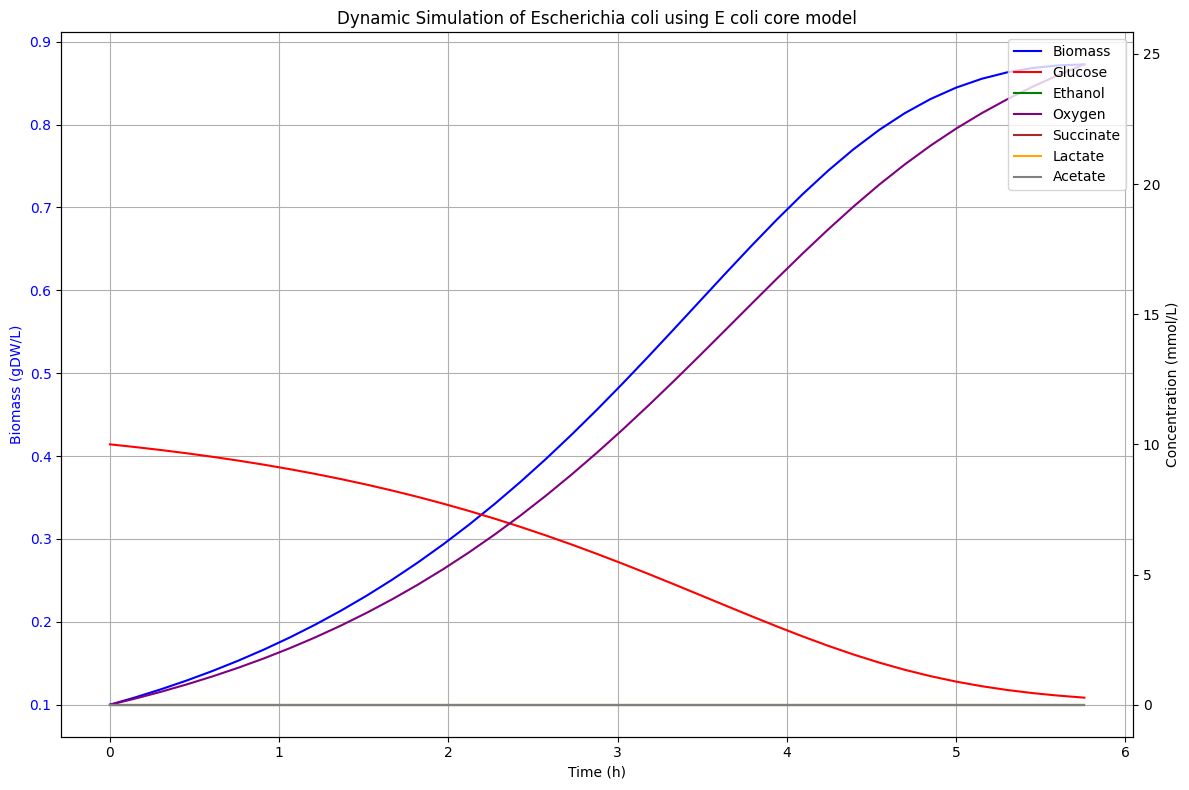

In [14]:
fig, ax1 = plt.subplots(figsize=(12, 8))

# Plot Biomass on the left Y-axis
ax1.plot(sol.t, sol.y.T[:, 0], color='blue', label='Biomass')
ax1.set_ylabel('Biomass (gDW/L)', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

# Create a twin Y-axis for Glucose, Ethanol, Oxygen, Succinate, Lactate, and Acetate
ax2 = ax1.twinx()
ax2.plot(sol.t, sol.y.T[:, 1], color='red', label='Glucose')
ax2.plot(sol.t, sol.y.T[:, 2], color='green', label='Ethanol')
ax2.plot(sol.t, np.abs(sol.y.T[:, 3]), color='purple', label='Oxygen') # Use absolute value for oxygen
ax2.plot(sol.t, sol.y.T[:, 4], color='brown', label='Succinate')
ax2.plot(sol.t, sol.y.T[:, 5], color='orange', label='Lactate')
ax2.plot(sol.t, sol.y.T[:, 6], color='gray', label='Acetate')
ax2.set_ylabel('Concentration (mmol/L)', color='black') # General label for the right axis
ax2.tick_params(axis='y', labelcolor='black')

# Set X-axis label and Title
ax1.set_xlabel('Time (h)')
ax1.set_title('Dynamic Simulation of Escherichia coli using E coli core model')
ax1.grid(True)

# Combine legends from both axes
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc='upper right')

plt.tight_layout()
plt.show()

Ahora veamos como es la producción bajo condiciones anaerobicas

In [15]:
model = load_model(model_to_use) # asegura el modelo sin modficiaciones
model.reactions.get_by_id("EX_o2_e").lower_bound = 0

ts = np.linspace(0, 15, 100)  # Desired integration resolution and interval
y0 = [0.1, 10, 0, 0, 0, 0, 0] # Initial conditions for [biomass, glucose, ethanol, oxygen, succinate, lactate, acetate]

with tqdm() as pbar:
    dynamic_system.pbar = pbar

    sol = solve_ivp(
        fun=dynamic_system,
        events=[infeasible_event],
        t_span=(ts.min(), ts.max()),
        y0=y0,
        t_eval=ts,
        rtol=1e-6,
        atol=1e-8,
        method='BDF'
    )

sol

t = 9.877: : 125it [00:22,  5.53it/s]


  message: A termination event occurred.
  success: True
   status: 1
        t: [ 0.000e+00  1.515e-01 ...  9.697e+00  9.848e+00]
        y: [[ 1.000e-01  1.017e-01 ...  1.947e-01  1.947e-01]
            [ 1.000e+01  9.898e+00 ...  2.302e+00  2.211e+00]
            ...
            [ 0.000e+00  8.712e-16 ... -6.564e-15 -6.207e-15]
            [ 0.000e+00  8.982e-02 ...  7.028e+00  7.120e+00]]
      sol: None
 t_events: [array([ 9.874e+00])]
 y_events: [array([[ 1.947e-01,  2.195e+00,  7.035e+00, -2.411e-15,
                    8.833e-15, -6.260e-15,  7.135e+00]])]
     nfev: 99
     njev: 2
      nlu: 11

### Crear el grafico de tiempo vs biomasa y glucosa en condiciones anaerobicas

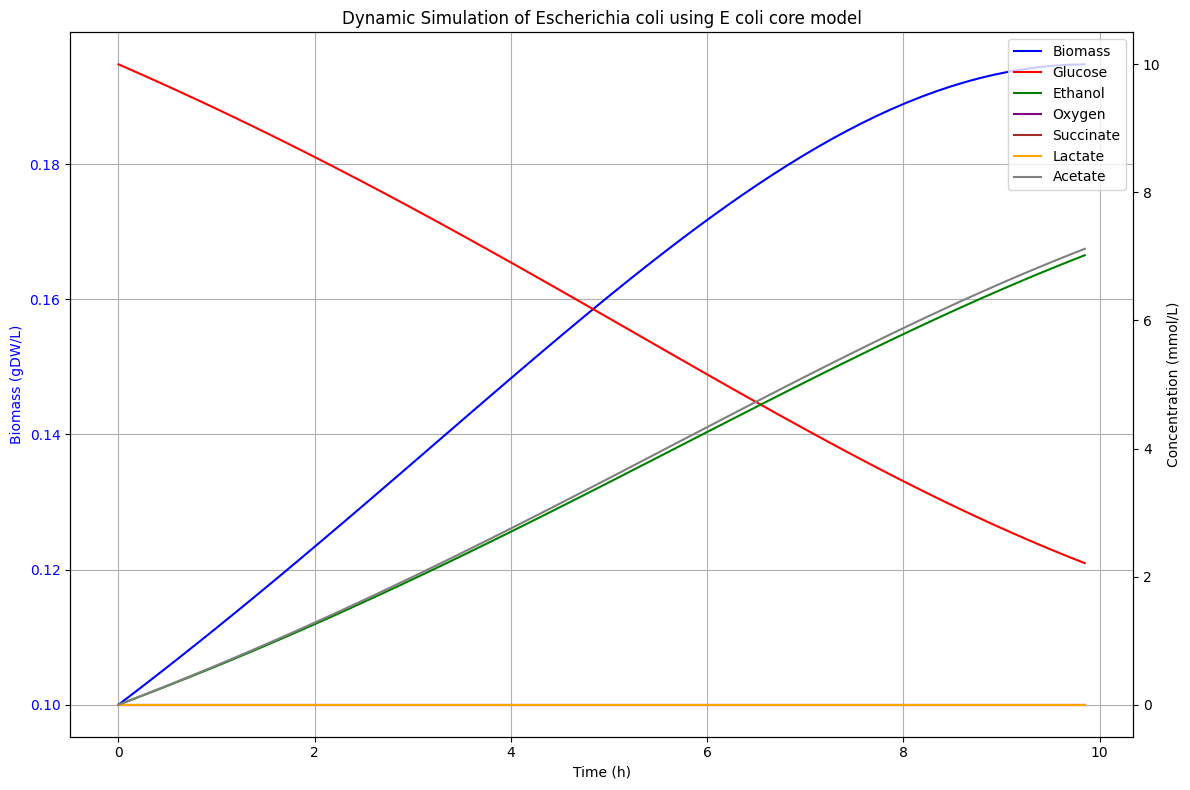

In [16]:
fig, ax1 = plt.subplots(figsize=(12, 8))

# Plot Biomass on the left Y-axis
ax1.plot(sol.t, sol.y.T[:, 0], color='blue', label='Biomass')
ax1.set_ylabel('Biomass (gDW/L)', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

# Create a twin Y-axis for Glucose, Ethanol, Oxygen, Succinate, Lactate, and Acetate
ax2 = ax1.twinx()
ax2.plot(sol.t, sol.y.T[:, 1], color='red', label='Glucose')
ax2.plot(sol.t, sol.y.T[:, 2], color='green', label='Ethanol')
ax2.plot(sol.t, np.abs(sol.y.T[:, 3]), color='purple', label='Oxygen') # Use absolute value for oxygen
ax2.plot(sol.t, sol.y.T[:, 4], color='brown', label='Succinate')
ax2.plot(sol.t, sol.y.T[:, 5], color='orange', label='Lactate')
ax2.plot(sol.t, sol.y.T[:, 6], color='gray', label='Acetate')
ax2.set_ylabel('Concentration (mmol/L)', color='black') # General label for the right axis
ax2.tick_params(axis='y', labelcolor='black')

# Set X-axis label and Title
ax1.set_xlabel('Time (h)')
ax1.set_title('Dynamic Simulation of Escherichia coli using E coli core model')
ax1.grid(True)

# Combine legends from both axes
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc='upper right')

plt.tight_layout()
plt.show()

## Conexión con el módulo

```
Genoma anotado          ->  model.genes  (reglas GPR)
Reacciones bioquímicas  ->  model.reactions + model.metabolites
Matriz estequiométrica  ->  create_stoichiometric_matrix(model)  -> S·v = 0
FBA                     ->  model.optimize()
Knockout                ->  rxn.knock_out() / single_gene_deletion()
Diseño de biofábrica    ->  cambiar objetivo + production_envelope()
Restricción enzimática  ->  v_i <= kcat_i · [E_i]  (GECKO)